> **Update (Feb 2026):** The core logic from this notebook has been ported to the production backend application at `app/backend/broll/`. This notebook serves as a research prototype and experimentation playground.

# 🎬 Keyframe Extraction & Description for B-Roll Semantic Search

This notebook extracts keyframes from video files using scene change detection and generates semantic descriptions using GPT-4o Vision via Azure AI Inference SDK.

## Features
- 🎯 **Scene Change Detection** using OpenCV histogram comparison
- 🧠 **AI-Powered Descriptions** via Azure AI Inference (GitHub Models)
- 📹 **Batch Processing** of multiple video files in `sample_videos/`
- 📊 **Visual Output** with inline keyframe display
- 💾 **Structured Data** ready for embedding and semantic search

## Parameters to Tune
- `SCENE_THRESHOLD`: Histogram difference threshold (0.0-1.0) for detecting scene changes
  - Lower values = more sensitive (more keyframes)
  - Higher values = less sensitive (fewer keyframes)
  - Typical range: 0.3-0.7
- `MIN_FRAME_INTERVAL`: Minimum frames between keyframes to avoid rapid cuts

## Future Integration
- Embed descriptions using `text-embedding-3-small`
- Store in vector database (ChromaDB, FAISS) for semantic search
- Match B-roll to story segments based on transcript topics

## Setup & Imports

In [ ]:
import cv2
import numpy as np
from pathlib import Path
import base64
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
from dotenv import load_dotenv
from typing import List, Dict, Tuple
import time

# Azure AI Inference SDK (The "Microsoft/Copilot" native way)
from azure.ai.inference import ChatCompletionsClient
from azure.ai.inference.models import SystemMessage, UserMessage, TextContentItem, ImageContentItem, ImageUrl
from azure.core.credentials import AzureKeyCredential

load_dotenv()

# Setup for GitHub Models
token = os.getenv("GITHUB_TOKEN")

if not token:
    print("⚠️  Warning: GITHUB_TOKEN not found.")
    print("   Please create a .env file with: GITHUB_TOKEN=ghp_...")
    # For fail-safe, we just raise error here as user specifically requested non-OpenAI SDK
    raise ValueError("GITHUB_TOKEN is required for this configuration.")

# Initialize the Microsoft Azure AI Inference Client
client = ChatCompletionsClient(
    endpoint="https://models.inference.ai.azure.com",
    credential=AzureKeyCredential(token),
)

print("✓ Libraries imported successfully")
print("✓ Client: Azure AI Inference (GitHub Models)")

✓ Libraries imported successfully
✓ Client: Azure AI Inference (GitHub Models)


## Configuration

In [16]:
# Video input - Process all videos in sample_videos directory
VIDEO_DIR = Path("sample_videos")
VIDEO_PATHS = sorted(VIDEO_DIR.glob("*.mp4"))

# Keyframe detection parameters
SCENE_THRESHOLD = 0.5  # Histogram difference threshold (0.0-1.0)
MIN_FRAME_INTERVAL = 30  # Minimum frames between keyframes (e.g., 30 frames = 1 second at 30fps)

# Output parameters
OUTPUT_DIR = Path("keyframes_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"📁 Output directory: {OUTPUT_DIR}")
print(f"📹 Found {len(VIDEO_PATHS)} videos to process:")
for vp in VIDEO_PATHS:
    print(f"   - {vp.name}")
print(f"🎯 Scene threshold: {SCENE_THRESHOLD}")
print(f"⏱️  Min frame interval: {MIN_FRAME_INTERVAL}")

📁 Output directory: keyframes_output
📹 Found 5 videos to process:
   - 20260211_124354.mp4
   - 20260211_214142.mp4
   - PXL_20260211_163832954.mp4
   - PXL_20260211_174712061.mp4
   - PXL_20260212_103601593.mp4
🎯 Scene threshold: 0.5
⏱️  Min frame interval: 30


## Keyframe Extraction Functions

In [17]:
def calculate_histogram_diff(frame1: np.ndarray, frame2: np.ndarray) -> float:
    """
    Calculate histogram difference between two frames.
    Returns a value between 0.0 (identical) and 1.0 (completely different).
    """
    # Convert to HSV color space for better color comparison
    hsv1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2HSV)
    hsv2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2HSV)
    
    # Calculate histograms for each channel
    hist1 = cv2.calcHist([hsv1], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
    hist2 = cv2.calcHist([hsv2], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
    
    # Normalize histograms
    hist1 = cv2.normalize(hist1, hist1).flatten()
    hist2 = cv2.normalize(hist2, hist2).flatten()
    
    # Compare using correlation method (1.0 = identical, 0.0 = different)
    correlation = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
    
    # Convert to difference score (0.0 = identical, 1.0 = different)
    return 1.0 - correlation


def extract_keyframes(video_path: str, 
                     threshold: float = 0.5, 
                     min_interval: int = 30) -> List[Dict]:
    """
    Extract keyframes from video using scene change detection.
    
    Args:
        video_path: Path to video file
        threshold: Histogram difference threshold for scene change
        min_interval: Minimum frames between keyframes
    
    Returns:
        List of dicts containing frame info (frame, timestamp, frame_number)
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        raise ValueError(f"Cannot open video file: {video_path}")
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"\n📹 Video info:")
    print(f"  - FPS: {fps}")
    print(f"  - Total frames: {total_frames}")
    print(f"  - Duration: {total_frames/fps:.2f} seconds")
    
    keyframes = []
    prev_frame = None
    last_keyframe_idx = -min_interval
    frame_idx = 0
    
    # Always add first frame as keyframe
    ret, first_frame = cap.read()
    if ret:
        keyframes.append({
            'frame': first_frame.copy(),
            'timestamp': 0.0,
            'frame_number': 0
        })
        prev_frame = first_frame
        last_keyframe_idx = 0
        frame_idx = 1
    
    print("\n🔍 Detecting scene changes...")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Show progress
        if frame_idx % 100 == 0:
            print(f"  Processing frame {frame_idx}/{total_frames} ({frame_idx/total_frames*100:.1f}%)")
        
        # Check if enough frames have passed since last keyframe
        if frame_idx - last_keyframe_idx >= min_interval:
            diff = calculate_histogram_diff(prev_frame, frame)
            
            if diff > threshold:
                timestamp = frame_idx / fps
                keyframes.append({
                    'frame': frame.copy(),
                    'timestamp': timestamp,
                    'frame_number': frame_idx
                })
                last_keyframe_idx = frame_idx
                print(f"  ✓ Keyframe detected at {timestamp:.2f}s (frame {frame_idx}, diff={diff:.3f})")
        
        prev_frame = frame
        frame_idx += 1
    
    cap.release()
    
    print(f"\n✅ Extracted {len(keyframes)} keyframes")
    return keyframes


print("✓ Keyframe extraction functions defined")

✓ Keyframe extraction functions defined


## GPT-4o Vision Description Functions

In [18]:
def encode_frame_to_base64(frame: np.ndarray, max_size: int = 512) -> str:
    """
    Encode OpenCV frame to base64 string for API transmission.
    Resizes to max_size to reduce API costs.
    """
    # Convert BGR to RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Resize to reduce API costs
    height, width = rgb_frame.shape[:2]
    if max(height, width) > max_size:
        scale = max_size / max(height, width)
        new_width = int(width * scale)
        new_height = int(height * scale)
        rgb_frame = cv2.resize(rgb_frame, (new_width, new_height))
    
    # Convert to PIL Image
    pil_img = Image.fromarray(rgb_frame)
    
    # Encode to base64
    buffer = BytesIO()
    pil_img.save(buffer, format="JPEG", quality=85)
    img_bytes = buffer.getvalue()
    
    return base64.b64encode(img_bytes).decode('utf-8')


def describe_frame_with_gpt4o(frame: np.ndarray, 
                              timestamp: float,
                              retry_count: int = 3) -> str:
    """
    Generate a semantic description of a video frame using GPT-4o via Azure AI SDK.
    """
    base64_image = encode_frame_to_base64(frame)
    
    prompt_text = """Describe this video frame in detail for semantic search purposes. Include:
- The main subject(s) and their actions
- The setting/environment
- Notable objects or elements
- The mood or atmosphere
- Any text visible in the frame

Keep it concise but informative (2-3 sentences)."""
    
    for attempt in range(retry_count):
        try:
            # Using Azure AI Inference SDK structure
            response = client.complete(
                model="gpt-4o",
                messages=[
                    UserMessage(
                        content=[
                            TextContentItem(text=prompt_text),
                            ImageContentItem(
                                image_url=ImageUrl(
                                    url=f"data:image/jpeg;base64,{base64_image}"
                                )
                            ),
                        ]
                    )
                ],
                max_tokens=300
            )
            
            description = response.choices[0].message.content.strip()
            return description
            
        except Exception as e:
            if attempt < retry_count - 1:
                print(f"  ⚠️  API error at {timestamp:.2f}s (attempt {attempt+1}/{retry_count}): {e}")
                time.sleep(2 ** attempt)
            else:
                print(f"  ❌ Failed to describe frame at {timestamp:.2f}s: {e}")
                return f"[Error: Could not generate description - {str(e)}]"
    
    return "[Error: Max retries exceeded]"


def describe_keyframes(keyframes: List[Dict]) -> List[Dict]:
    """
    Generate descriptions for all keyframes.
    """
    print(f"\n🧠 Generating descriptions for {len(keyframes)} keyframes...")
    
    for idx, kf in enumerate(keyframes):
        print(f"\n  [{idx+1}/{len(keyframes)}] Processing frame at {kf['timestamp']:.2f}s...")
        description = describe_frame_with_gpt4o(kf['frame'], kf['timestamp'])
        kf['description'] = description
        print(f"  ✓ {description}")
        
        if idx < len(keyframes) - 1:
            time.sleep(1.0)
    
    print("\n✅ All descriptions generated")
    return keyframes


print("✓ GPT-4o Vision functions defined (Azure AI SDK)")

✓ GPT-4o Vision functions defined (Azure AI SDK)


## Visualization Functions

In [19]:
def display_keyframes(keyframes: List[Dict], max_cols: int = 3):
    """
    Display keyframes in a grid with their descriptions.
    
    Args:
        keyframes: List of keyframe dicts with 'frame', 'timestamp', and 'description'
        max_cols: Maximum number of columns in the grid
    """
    n_frames = len(keyframes)
    n_cols = min(max_cols, n_frames)
    n_rows = (n_frames + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))
    
    # Ensure axes is always 2D array
    if n_frames == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, kf in enumerate(keyframes):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]
        
        # Convert BGR to RGB for display
        rgb_frame = cv2.cvtColor(kf['frame'], cv2.COLOR_BGR2RGB)
        
        ax.imshow(rgb_frame)
        ax.axis('off')
        
        # Add timestamp and description
        title = f"Frame {kf['frame_number']} @ {kf['timestamp']:.2f}s"
        description = kf.get('description', 'No description')
        
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
        
        # Add description as text below image
        ax.text(0.5, -0.1, description, 
               transform=ax.transAxes,
               ha='center', va='top',
               fontsize=9,
               wrap=True,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # Hide empty subplots
    for idx in range(n_frames, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()


print("✓ Visualization functions defined")

✓ Visualization functions defined


## Run Pipeline

Execute the full keyframe extraction and description pipeline.

In [20]:
# Step 1: Extract keyframes from ALL videos
all_videos_keyframes = []

for video_path in VIDEO_PATHS:
    print(f"\n{'='*80}")
    print(f"Processing: {video_path.name}")
    print(f"{'='*80}")
    
    keyframes = extract_keyframes(
        video_path=str(video_path),
        threshold=SCENE_THRESHOLD,
        min_interval=MIN_FRAME_INTERVAL
    )
    
    # Tag each keyframe with its source video
    for kf in keyframes:
        kf['video_name'] = video_path.name
        kf['video_path'] = str(video_path)
    
    all_videos_keyframes.extend(keyframes)
    print(f"✓ Extracted {len(keyframes)} keyframes from {video_path.name}")

print(f"\n{'='*80}")
print(f"✅ Total keyframes extracted: {len(all_videos_keyframes)}")
print(f"{'='*80}")


Processing: 20260211_124354.mp4

📹 Video info:
  - FPS: 29.542890174544134
  - Total frames: 1205
  - Duration: 40.79 seconds



🔍 Detecting scene changes...
  Processing frame 100/1205 (8.3%)
  Processing frame 200/1205 (16.6%)
  Processing frame 300/1205 (24.9%)
  Processing frame 400/1205 (33.2%)
  Processing frame 500/1205 (41.5%)
  Processing frame 600/1205 (49.8%)
  Processing frame 700/1205 (58.1%)
  Processing frame 800/1205 (66.4%)
  Processing frame 900/1205 (74.7%)
  Processing frame 1000/1205 (83.0%)
  Processing frame 1100/1205 (91.3%)
  Processing frame 1200/1205 (99.6%)

✅ Extracted 1 keyframes
✓ Extracted 1 keyframes from 20260211_124354.mp4

Processing: 20260211_214142.mp4

📹 Video info:
  - FPS: 29.345568625618167
  - Total frames: 893
  - Duration: 30.43 seconds

🔍 Detecting scene changes...
  Processing frame 100/893 (11.2%)
  ✓ Keyframe detected at 4.02s (frame 118, diff=0.677)
  Processing frame 200/893 (22.4%)
  Processing frame 300/893 (33.6%)
  Processing frame 400/893 (44.8%)
  Processing frame 500/893 (56.0%)
  Processing frame 600/893 (67.2%)
  Processing frame 700/893 (78.4%)
  Proc

In [21]:
# Step 2: Generate descriptions using GPT-4o Vision for ALL keyframes
keyframes_with_descriptions = describe_keyframes(all_videos_keyframes)


🧠 Generating descriptions for 6 keyframes...

  [1/6] Processing frame at 0.00s...
  ✓ The frame captures a skier in mustard-yellow pants and a black top standing on a snowy slope, appearing to adjust or hold ski poles. The setting is a bright, sunny mountain terrain with rugged, snow-covered rocky peaks in the background under a partly cloudy blue sky. The mood is adventurous and serene, with no visible text in the frame.

  [2/6] Processing frame at 0.00s...
  ✓ This video frame captures a curling competition in a brightly lit indoor arena filled with spectators. Several players are on the ice engaged in the game, with curling stones and target circles visible on multiple lanes. The setting is vibrant, with blue-themed event branding that includes visible Olympic rings and screens displaying live coverage, creating an energetic and competitive atmosphere.

  [3/6] Processing frame at 4.02s...
  ✓ This video frame depicts a curling competition in an indoor Olympic arena, with multipl

/tmp/ipykernel_19045/3315007970.py:54: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


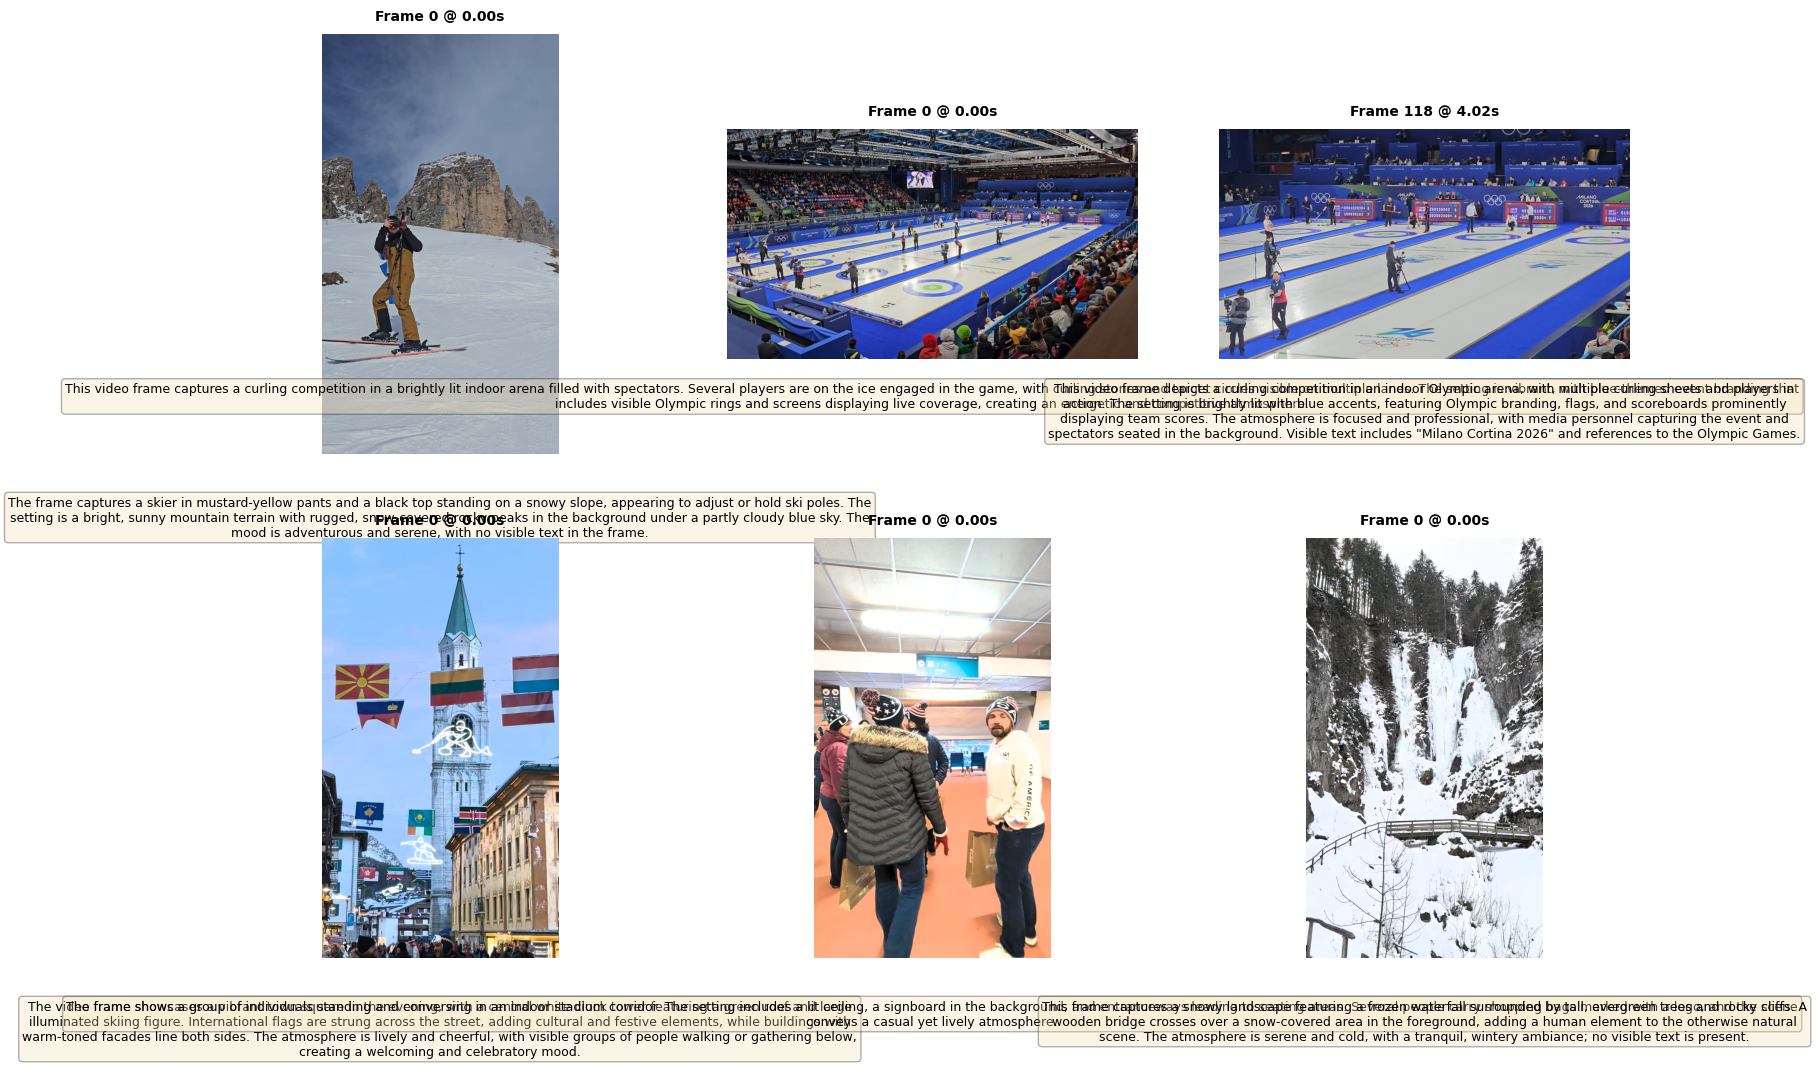

In [22]:
# Step 3: Visualize results
display_keyframes(keyframes_with_descriptions, max_cols=3)

## Save Results

Save keyframes and metadata for future embedding/search integration.

In [23]:
import json

# Save individual keyframes as images with video name prefix
for idx, kf in enumerate(keyframes_with_descriptions):
    video_name = Path(kf.get('video_name', 'unknown')).stem
    frame_path = OUTPUT_DIR / f"{video_name}_keyframe_{idx:03d}_{kf['timestamp']:.2f}s.jpg"
    cv2.imwrite(str(frame_path), kf['frame'])

# Save metadata as JSON (without the actual frame data)
metadata = []
for idx, kf in enumerate(keyframes_with_descriptions):
    video_name = Path(kf.get('video_name', 'unknown')).stem
    metadata.append({
        'index': idx,
        'video_name': kf.get('video_name', 'unknown'),
        'video_path': kf.get('video_path', ''),
        'timestamp': kf['timestamp'],
        'frame_number': kf['frame_number'],
        'description': kf['description'],
        'image_path': f"{video_name}_keyframe_{idx:03d}_{kf['timestamp']:.2f}s.jpg"
    })

metadata_path = OUTPUT_DIR / "keyframes_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n✅ Saved {len(keyframes_with_descriptions)} keyframes to {OUTPUT_DIR}")
print(f"✅ Saved metadata to {metadata_path}")
print("\n📊 Summary by video:")

# Group by video
from collections import defaultdict
by_video = defaultdict(list)
for item in metadata:
    by_video[item['video_name']].append(item)

for video_name, items in sorted(by_video.items()):
    print(f"\n{video_name}: {len(items)} keyframes")
    for item in items[:3]:  # Show first 3 per video
        print(f"  - [{item['timestamp']:.2f}s] {item['description'][:60]}...")
    if len(items) > 3:
        print(f"  ... and {len(items)-3} more")


✅ Saved 6 keyframes to keyframes_output
✅ Saved metadata to keyframes_output/keyframes_metadata.json

📊 Summary by video:

20260211_124354.mp4: 1 keyframes
  - [0.00s] The frame captures a skier in mustard-yellow pants and a bla...

20260211_214142.mp4: 2 keyframes
  - [0.00s] This video frame captures a curling competition in a brightl...
  - [4.02s] This video frame depicts a curling competition in an indoor ...

PXL_20260211_163832954.mp4: 1 keyframes
  - [0.00s] The video frame showcases a vibrant town square in the eveni...

PXL_20260211_174712061.mp4: 1 keyframes
  - [0.00s] The frame shows a group of individuals standing and conversi...

PXL_20260212_103601593.mp4: 1 keyframes
  - [0.00s] This frame captures a snowy landscape featuring a frozen wat...


## Semantic Search with Key Terms

In [24]:
import json
import numpy as np
from typing import List, Dict
from sklearn.metrics.pairwise import cosine_similarity

# Try to use Azure AI for embeddings, fallback to sentence-transformers
try:
    from azure.ai.inference import EmbeddingsClient
    from azure.core.credentials import AzureKeyCredential
    
    embedding_client = EmbeddingsClient(
        endpoint="https://models.inference.ai.azure.com",
        credential=AzureKeyCredential(token)
    )
    
    def get_embeddings(texts: List[str]) -> np.ndarray:
        """Get embeddings using Azure AI Inference"""
        response = embedding_client.embed(
            input=texts,
            model="text-embedding-3-small"
        )
        return np.array([item.embedding for item in response.data])
    
    print("✓ Using Azure AI Inference for embeddings")
    
except (ImportError, Exception) as e:
    print(f"⚠️  Azure AI embeddings not available: {e}")
    print("   Falling back to sentence-transformers...")
    
    from sentence_transformers import SentenceTransformer
    
    model = SentenceTransformer('all-MiniLM-L6-v2')
    
    def get_embeddings(texts: List[str]) -> np.ndarray:
        """Get embeddings using sentence-transformers"""
        return model.encode(texts, convert_to_numpy=True)
    
    print("✓ Using sentence-transformers (all-MiniLM-L6-v2)")

✓ Using Azure AI Inference for embeddings


In [25]:
def generate_key_terms(description: str) -> List[str]:
    """Generate key terms/tags from description using LLM"""
    prompt = f"""Extract 5-8 key terms or tags from this video keyframe description.
Return only a comma-separated list of single words or short phrases.

Description: {description}

Key terms:"""
    
    response = client.complete(
        messages=[
            SystemMessage(content="You extract key terms and tags from descriptions. Return only comma-separated terms."),
            UserMessage(content=prompt)
        ],
        model="gpt-4o-mini",
        temperature=0.3,
        max_tokens=100
    )
    
    terms_text = response.choices[0].message.content.strip()
    terms = [t.strip() for t in terms_text.split(',')]
    return terms

# Generate key terms for all keyframes
print("Generating key terms for each keyframe...")
keyframe_data = []

for idx, kf in enumerate(keyframes_with_descriptions):
    terms = generate_key_terms(kf['description'])
    terms_text = ', '.join(terms)
    
    keyframe_data.append({
        'index': idx,
        'timestamp': kf['timestamp'],
        'description': kf['description'],
        'key_terms': terms,
        'terms_text': terms_text,
        'frame': kf['frame']
    })
    
    print(f"[{idx}] {kf['timestamp']:.2f}s: {terms_text}")
    time.sleep(0.5)  # Rate limiting

print(f"\n✓ Generated key terms for {len(keyframe_data)} keyframes")

Generating key terms for each keyframe...
[0] 0.00s: skier, mustard-yellow, snowy slope, ski poles, mountain terrain, rocky peaks, adventurous, serene
[1] 0.00s: curling, competition, indoor arena, spectators, players, stones, Olympic rings, vibrant
[2] 4.02s: curling, competition, Olympic, arena, players, scoreboards, Milano Cortina 2026, spectators
[3] 0.00s: town square, clock tower, skiing figure, international flags, festive, warm-toned, lively, cheerful
[4] 0.00s: group, individuals, indoor, stadium, corridor, shopping bags, casual, lively
[5] 0.00s: snow, waterfall, evergreen, trees, cliffs, bridge, serene, winter

✓ Generated key terms for 6 keyframes


In [26]:
# Create embeddings for all key terms
print("Creating embeddings for key terms...")
terms_texts = [kf['terms_text'] for kf in keyframe_data]
keyframe_embeddings = get_embeddings(terms_texts)

print(f"✓ Created {len(keyframe_embeddings)} embeddings")
print(f"  Embedding dimension: {keyframe_embeddings.shape[1]}")

Creating embeddings for key terms...
✓ Created 6 embeddings
  Embedding dimension: 1536


In [27]:
def semantic_search(query: str, top_k: int = 3):
    """Search keyframes by semantic similarity to query"""
    # Embed the query
    query_embedding = get_embeddings([query])
    
    # Calculate cosine similarity
    similarities = cosine_similarity(query_embedding, keyframe_embeddings)[0]
    
    # Get top-k matches
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    # Display results
    print(f"\n🔍 Search: '{query}'\n")
    print("=" * 80)
    
    results = []
    for rank, idx in enumerate(top_indices, 1):
        kf = keyframe_data[idx]
        score = similarities[idx]
        
        print(f"\n#{rank} - Match Score: {score:.3f}")
        print(f"Video: {kf.get('video_name', 'unknown')}")
        print(f"Timestamp: {kf['timestamp']:.2f}s")
        print(f"Key Terms: {kf['terms_text']}")
        print(f"Description: {kf['description'][:150]}...")
        print("-" * 80)
        
        results.append((kf, score))
    
    # Display keyframe images
    fig, axes = plt.subplots(1, top_k, figsize=(15, 5))
    if top_k == 1:
        axes = [axes]
    
    for idx, (kf, score) in enumerate(results):
        frame_rgb = cv2.cvtColor(kf['frame'], cv2.COLOR_BGR2RGB)
        axes[idx].imshow(frame_rgb)
        video_name = Path(kf.get('video_name', 'unknown')).stem[:20]
        axes[idx].set_title(f"#{idx+1} - {video_name}\n{kf['timestamp']:.2f}s | Score: {score:.3f}", fontsize=9)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return results

print("✓ Semantic search function ready!")
print("\nExample usage:")
print("  semantic_search('people talking')")
print("  semantic_search('outdoor scene')")
print("  semantic_search('text or graphics')")

✓ Semantic search function ready!

Example usage:
  semantic_search('people talking')
  semantic_search('outdoor scene')
  semantic_search('text or graphics')



🔍 Search: 'ice water fall climbing'


#1 - Match Score: 0.455
Video: unknown
Timestamp: 0.00s
Key Terms: snow, waterfall, evergreen, trees, cliffs, bridge, serene, winter
Description: This frame captures a snowy landscape featuring a frozen waterfall surrounded by tall, evergreen trees and rocky cliffs. A wooden bridge crosses over ...
--------------------------------------------------------------------------------

#2 - Match Score: 0.349
Video: unknown
Timestamp: 0.00s
Key Terms: skier, mustard-yellow, snowy slope, ski poles, mountain terrain, rocky peaks, adventurous, serene
Description: The frame captures a skier in mustard-yellow pants and a black top standing on a snowy slope, appearing to adjust or hold ski poles. The setting is a ...
--------------------------------------------------------------------------------


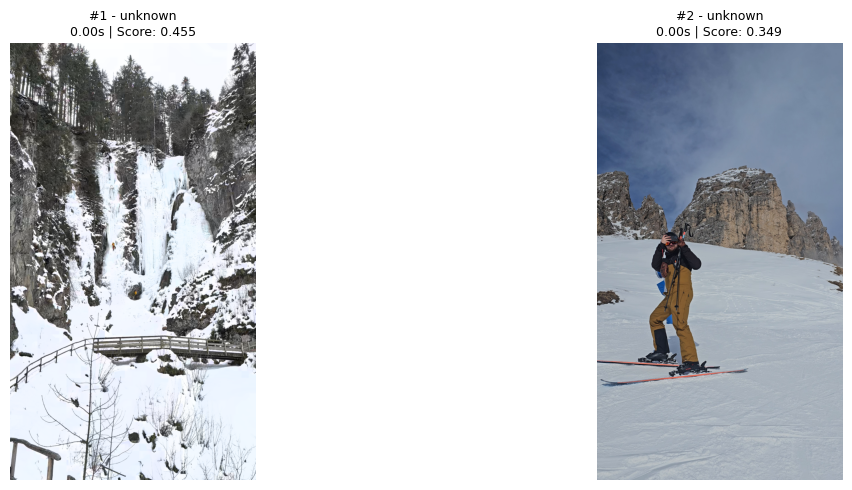

[({'index': 5,
   'timestamp': 0.0,
   'description': 'This frame captures a snowy landscape featuring a frozen waterfall surrounded by tall, evergreen trees and rocky cliffs. A wooden bridge crosses over a snow-covered area in the foreground, adding a human element to the otherwise natural scene. The atmosphere is serene and cold, with a tranquil, wintery ambiance; no visible text is present.',
   'key_terms': ['snow',
    'waterfall',
    'evergreen',
    'trees',
    'cliffs',
    'bridge',
    'serene',
    'winter'],
   'terms_text': 'snow, waterfall, evergreen, trees, cliffs, bridge, serene, winter',
   'frame': array([[[ 45,  51,  48],
           [ 56,  63,  60],
           [ 75,  82,  79],
           ...,
           [255, 245, 245],
           [255, 245, 245],
           [255, 245, 245]],
   
          [[ 40,  47,  44],
           [ 47,  53,  51],
           [ 69,  76,  73],
           ...,
           [255, 245, 245],
           [255, 245, 245],
           [255, 245, 245]],
   

In [32]:
# Try a search!
semantic_search('ice water fall climbing', top_k=2)